# Knee Osteoarthritis Severity Classification – Deep Learning Pipeline

**Task**: Multi-class classification of knee X-ray images into KL (Kellgren-Lawrence) grades 0–4.

| Grade | Label | Description |
|-------|-------|-------------|
| 0 | Healthy | No signs of osteoarthritis |
| 1 | Doubtful | Doubtful joint narrowing, possible osteophytic lipping |
| 2 | Minimal | Definite osteophytes, possible joint space narrowing |
| 3 | Moderate | Multiple osteophytes, definite joint space narrowing, mild sclerosis |
| 4 | Severe | Large osteophytes, significant joint narrowing, severe sclerosis |

**Pipeline**:
1. Data exploration & visualisation
2. Augmentation strategy & DataLoaders
3. Transfer learning with EfficientNet-B3
4. Class-weighted loss to handle imbalance
5. Training with early stopping & LR scheduling
6. Evaluation: confusion matrix, classification report, per-class metrics

## 1. Install Dependencies

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --quiet
# If no GPU / CUDA not available, use CPU-only build:
# %pip install torch torchvision torchaudio --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 3. Configuration

In [3]:
# --- Paths ---
DATA_DIR = Path('data')          # relative to this notebook
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

# --- Hyperparameters ---
NUM_CLASSES   = 5
IMG_SIZE      = 224          # EfficientNet-B3 default
BATCH_SIZE    = 32
NUM_EPOCHS    = 30
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 7            # early stopping patience

CLASS_NAMES   = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
GRADE_LABELS  = {0: 'Healthy', 1: 'Doubtful', 2: 'Minimal', 3: 'Moderate', 4: 'Severe'}

## 4. Data Exploration

In [4]:
# Count images per class per split
splits = {'train': TRAIN_DIR, 'val': VAL_DIR, 'test': TEST_DIR}
counts = {}
for split, path in splits.items():
    counts[split] = [len(list((path / str(g)).glob('*.*'))) for g in range(NUM_CLASSES)]

print(f"{'Grade':<8} {'Train':>8} {'Val':>8} {'Test':>8}")
print('-' * 36)
for g in range(NUM_CLASSES):
    label = GRADE_LABELS[g]
    print(f"{g} ({label:<8}) {counts['train'][g]:>8} {counts['val'][g]:>8} {counts['test'][g]:>8}")
print('-' * 36)
print(f"{'Total':<8} {sum(counts['train']):>8} {sum(counts['val']):>8} {sum(counts['test']):>8}")

Grade       Train      Val     Test
------------------------------------
0 (Healthy )     2286      328      639
1 (Doubtful)     1046      153      296
2 (Minimal )     1516      212      447
3 (Moderate)      757      106      223
4 (Severe  )      173       27       51
------------------------------------
Total        5778      826     1656


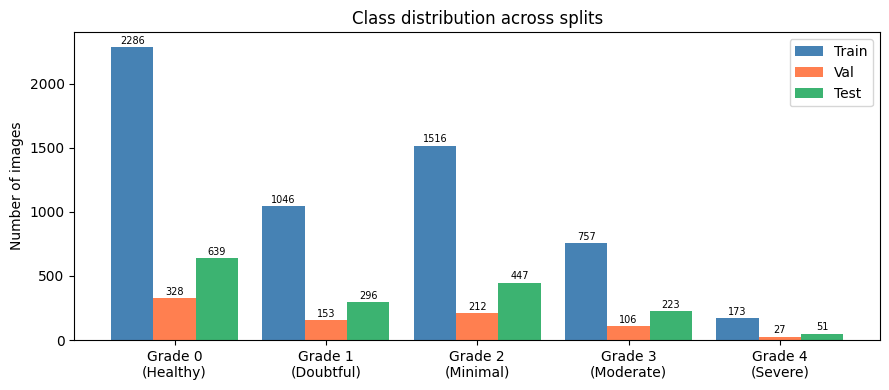

In [5]:
# Class distribution bar chart
x = np.arange(NUM_CLASSES)
width = 0.28
fig, ax = plt.subplots(figsize=(9, 4))
bars = [
    ax.bar(x - width, counts['train'], width, label='Train', color='steelblue'),
    ax.bar(x,         counts['val'],   width, label='Val',   color='coral'),
    ax.bar(x + width, counts['test'],  width, label='Test',  color='mediumseagreen'),
]
ax.set_xticks(x)
ax.set_xticklabels([f'Grade {g}\n({GRADE_LABELS[g]})' for g in range(NUM_CLASSES)])
ax.set_ylabel('Number of images')
ax.set_title('Class distribution across splits')
ax.legend()
for bar_group in bars:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

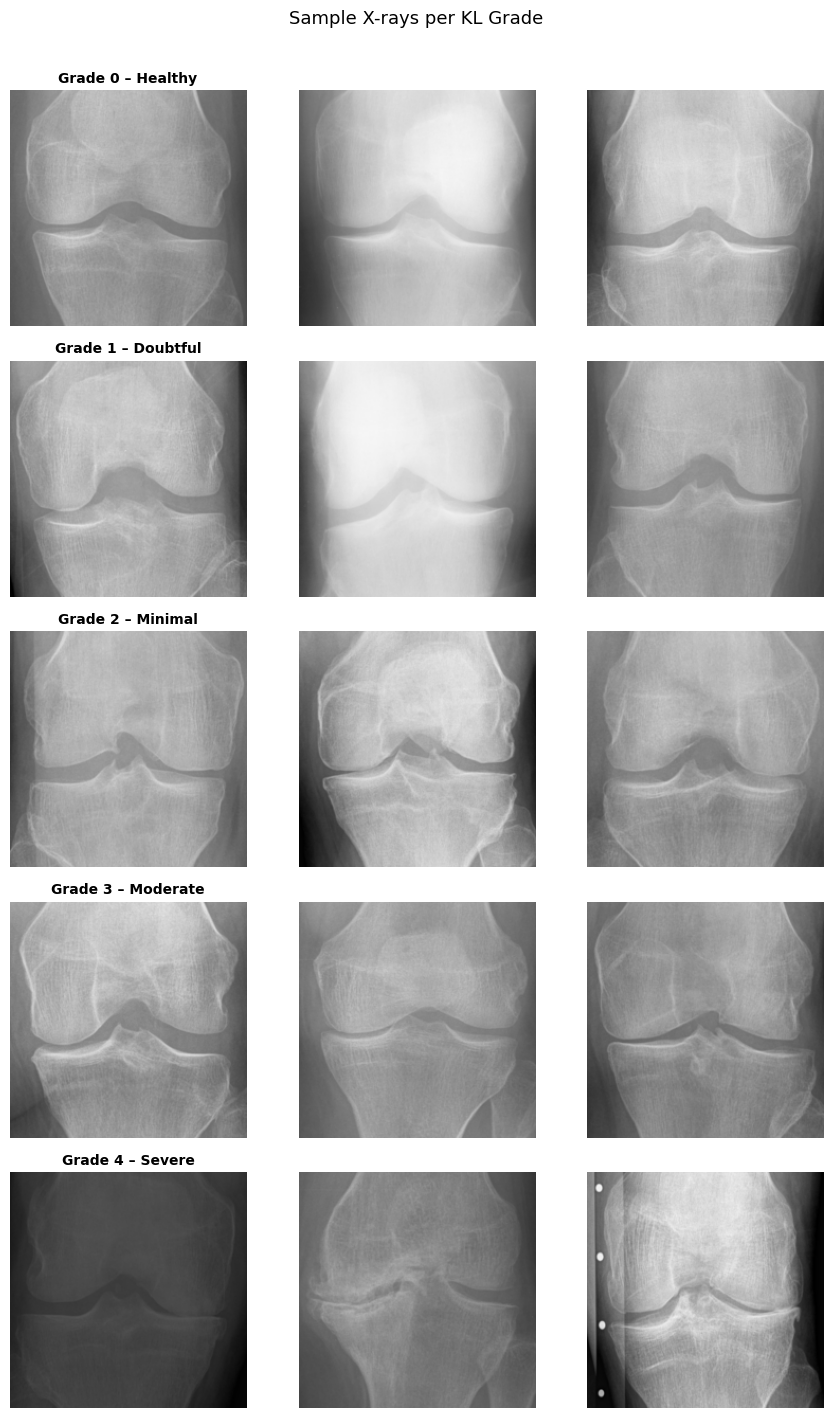

In [6]:
# Sample images – 3 per grade from training set
from PIL import Image

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(9, 14))
for g in range(NUM_CLASSES):
    imgs = sorted((TRAIN_DIR / str(g)).glob('*.png'))
    samples = random.sample(imgs, min(3, len(imgs)))
    for col, img_path in enumerate(samples):
        img = Image.open(img_path).convert('RGB')
        axes[g, col].imshow(img, cmap='gray')
        axes[g, col].axis('off')
        if col == 0:
            axes[g, col].set_title(f'Grade {g} – {GRADE_LABELS[g]}', fontsize=10, fontweight='bold')
plt.suptitle('Sample X-rays per KL Grade', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Data Augmentation & DataLoaders

**Strategy**:
- **Train**: Random horizontal flip, rotation (±10°), colour jitter, normalise (ImageNet stats)
- **Val / Test**: Resize, centre crop, normalise only

Aggressive augmentation is avoided because X-ray orientation has clinical meaning.

In [7]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Class-to-index mapping: {train_dataset.class_to_idx}')

Train: 5778 | Val: 826 | Test: 1656
Class-to-index mapping: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [8]:
# Compute class weights to handle imbalance (inverse-frequency weighting)
train_counts = np.array(counts['train'], dtype=float)
class_weights = torch.tensor(
    (train_counts.sum() / (NUM_CLASSES * train_counts)).astype(np.float32)
).to(DEVICE)

print('Class weights (higher = rarer class gets more penalty):')
for g, w in enumerate(class_weights.cpu().numpy()):
    print(f'  Grade {g} ({GRADE_LABELS[g]}): {w:.3f}')

Class weights (higher = rarer class gets more penalty):
  Grade 0 (Healthy): 0.506
  Grade 1 (Doubtful): 1.105
  Grade 2 (Minimal): 0.762
  Grade 3 (Moderate): 1.527
  Grade 4 (Severe): 6.680


## 6. Model – EfficientNet-B3 (Transfer Learning)

EfficientNet-B3 is chosen for medical imaging because:
- Strong ImageNet pretraining with compound scaling
- Good accuracy/parameter trade-off
- Better feature extraction for subtle texture differences in X-rays

**Fine-tuning strategy**: Freeze backbone → train classifier head for 5 epochs → unfreeze all layers → train end-to-end with lower LR.

In [9]:
def build_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    return model


model = build_model(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Trainable parameters: 789,509 / 11,485,741 (6.9%)


## 7. Training

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return running_loss / total, correct / total


def run_training(model, train_loader, val_loader, num_epochs, lr):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = torch.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        print(f'Epoch {epoch:>3}/{num_epochs} | '
              f'Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | '
              f'Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}')

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0
            torch.save(model.state_dict(), MODEL_DIR / 'best_efficientnet_b3.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
                break

    return history

In [11]:
# Phase 1: Train classifier head only (frozen backbone, 5 epochs)
print('=== Phase 1: Training classifier head (backbone frozen) ===')
history_phase1 = run_training(model, train_loader, val_loader, num_epochs=5, lr=LR)

=== Phase 1: Training classifier head (backbone frozen) ===
Epoch   1/5 | Train Loss: 1.5874  Acc: 0.3162 | Val Loss: 1.4834  Acc: 0.4140
Epoch   2/5 | Train Loss: 1.5196  Acc: 0.3647 | Val Loss: 1.4211  Acc: 0.4201
Epoch   3/5 | Train Loss: 1.4652  Acc: 0.3624 | Val Loss: 1.3612  Acc: 0.4358
Epoch   4/5 | Train Loss: 1.4443  Acc: 0.3718 | Val Loss: 1.3768  Acc: 0.4056
Epoch   5/5 | Train Loss: 1.4369  Acc: 0.3629 | Val Loss: 1.3730  Acc: 0.4116


In [12]:
# Phase 2: Unfreeze all layers and fine-tune end-to-end with lower LR
print('=== Phase 2: Fine-tuning entire network ===')
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

history_phase2 = run_training(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=LR / 10)

=== Phase 2: Fine-tuning entire network ===
Trainable parameters: 11,485,741
Epoch   1/30 | Train Loss: 1.4042  Acc: 0.3775 | Val Loss: 1.3078  Acc: 0.4358
Epoch   2/30 | Train Loss: 1.3261  Acc: 0.4145 | Val Loss: 1.2615  Acc: 0.4564
Epoch   3/30 | Train Loss: 1.2651  Acc: 0.4238 | Val Loss: 1.2063  Acc: 0.4758
Epoch   4/30 | Train Loss: 1.2043  Acc: 0.4493 | Val Loss: 1.1661  Acc: 0.5012
Epoch   5/30 | Train Loss: 1.1585  Acc: 0.4573 | Val Loss: 1.1344  Acc: 0.5182
Epoch   6/30 | Train Loss: 1.1108  Acc: 0.4927 | Val Loss: 1.1132  Acc: 0.5266
Epoch   7/30 | Train Loss: 1.0795  Acc: 0.4962 | Val Loss: 1.0971  Acc: 0.5375
Epoch   8/30 | Train Loss: 1.0511  Acc: 0.5116 | Val Loss: 1.0736  Acc: 0.5436
Epoch   9/30 | Train Loss: 1.0117  Acc: 0.5234 | Val Loss: 1.0450  Acc: 0.5605
Epoch  10/30 | Train Loss: 0.9937  Acc: 0.5308 | Val Loss: 1.0332  Acc: 0.5617
Epoch  11/30 | Train Loss: 0.9723  Acc: 0.5327 | Val Loss: 1.0188  Acc: 0.5654
Epoch  12/30 | Train Loss: 0.9537  Acc: 0.5438 | Val L

## 8. Learning Curves

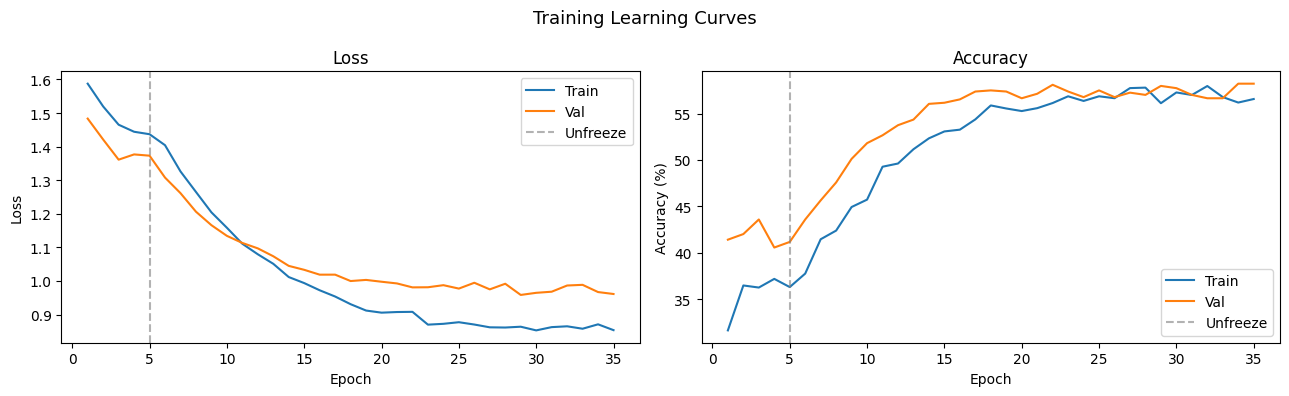

In [13]:
# Merge phase histories
def merge_histories(*histories):
    merged = {k: [] for k in histories[0]}
    for h in histories:
        for k in merged:
            merged[k].extend(h[k])
    return merged

history = merge_histories(history_phase1, history_phase2)
phase1_len = len(history_phase1['train_loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Val')
ax1.axvline(phase1_len, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss')
ax1.legend()

ax2.plot(epochs, [a * 100 for a in history['train_acc']], label='Train')
ax2.plot(epochs, [a * 100 for a in history['val_acc']],   label='Val')
ax2.axvline(phase1_len, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.set_title('Accuracy')
ax2.legend()

plt.suptitle('Training Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Evaluation on Test Set

In [14]:
# Load best checkpoint
model.load_state_dict(torch.load(MODEL_DIR / 'best_efficientnet_b3.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Test Accuracy: 0.6075 (60.75%)


In [15]:
# Classification report
print(classification_report(
    all_labels, all_preds,
    target_names=[f'Grade {g} ({GRADE_LABELS[g]})' for g in range(NUM_CLASSES)]
))

                    precision    recall  f1-score   support

 Grade 0 (Healthy)       0.65      0.88      0.75       639
Grade 1 (Doubtful)       0.27      0.18      0.22       296
 Grade 2 (Minimal)       0.64      0.40      0.50       447
Grade 3 (Moderate)       0.68      0.74      0.71       223
  Grade 4 (Severe)       0.64      0.88      0.74        51

          accuracy                           0.61      1656
         macro avg       0.58      0.62      0.58      1656
      weighted avg       0.58      0.61      0.58      1656



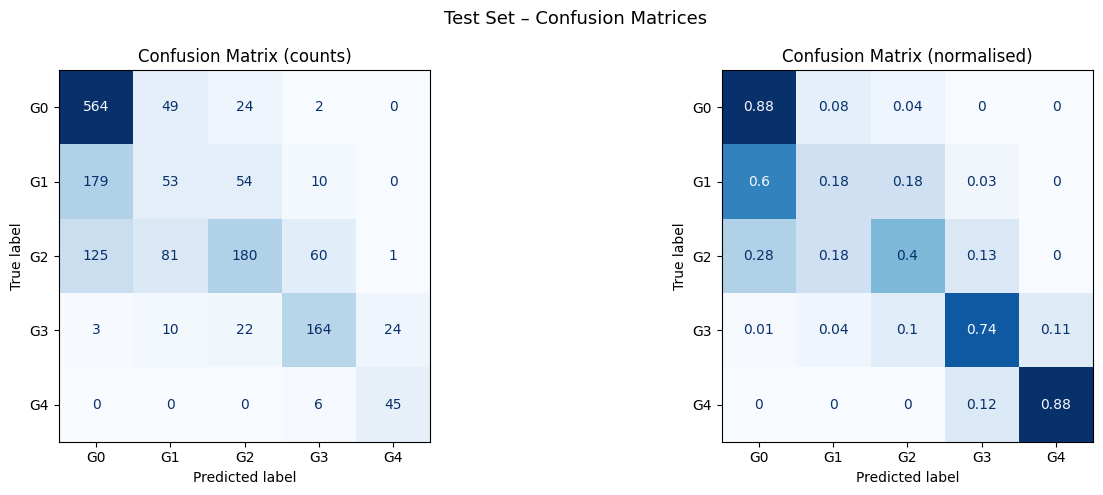

In [16]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[f'G{g}' for g in range(NUM_CLASSES)])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix (counts)')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=np.round(cm_norm, 2),
                                    display_labels=[f'G{g}' for g in range(NUM_CLASSES)])
disp_norm.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix (normalised)')

plt.suptitle('Test Set – Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

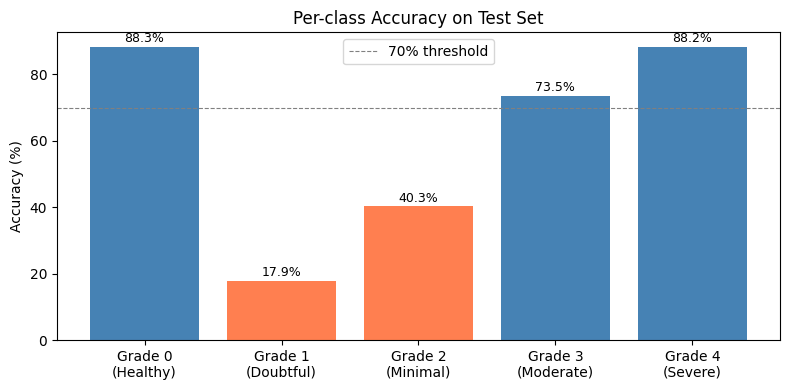

In [17]:
# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [f'Grade {g}\n({GRADE_LABELS[g]})' for g in range(NUM_CLASSES)],
    per_class_acc * 100,
    color=['steelblue' if a >= 0.7 else 'coral' for a in per_class_acc]
)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-class Accuracy on Test Set')
ax.axhline(70, color='gray', linestyle='--', linewidth=0.8, label='70% threshold')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Save Model & Artefacts

In [18]:
# Save full model checkpoint with metadata
checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'architecture': 'efficientnet_b3',
    'test_accuracy': float(test_acc),
    'history': history,
}
save_path = MODEL_DIR / 'knee_kl_efficientnet_b3_final.pth'
torch.save(checkpoint, save_path)
print(f'Model saved to: {save_path}')

Model saved to: models/knee_kl_efficientnet_b3_final.pth


## 11. Inference – Single Image

Helper function to predict the KL grade for a single X-ray image.

Image     : 9292027L.png
True grade: 0 (Healthy)
Predicted : 0 (Healthy)  confidence: 61.12%

Probabilities:
  Grade 0: ████████████████████████ 61.12%
  Grade 1: ██████████ 26.41%
  Grade 2: ███ 9.50%
  Grade 3:  2.36%
  Grade 4:  0.61%


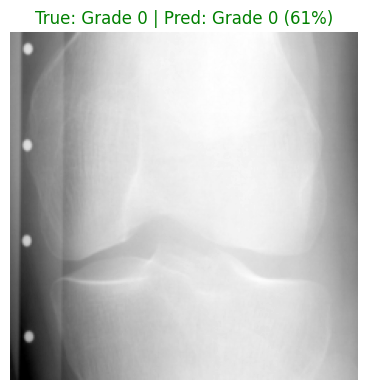

In [19]:
from PIL import Image

def predict_single(image_path: str, model: nn.Module) -> dict:
    img = Image.open(image_path).convert('RGB')
    tensor = eval_transforms(img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred   = int(probs.argmax())
    return {
        'predicted_grade': pred,
        'label': GRADE_LABELS[pred],
        'confidence': float(probs[pred]),
        'probabilities': {f'Grade {g}': float(p) for g, p in enumerate(probs)},
    }


# Example: run on a random test image
sample_paths = list(TEST_DIR.rglob('*.png'))
sample = random.choice(sample_paths)
true_grade = int(sample.parent.name)

result = predict_single(sample, model)
print(f'Image     : {sample.name}')
print(f'True grade: {true_grade} ({GRADE_LABELS[true_grade]})')
print(f'Predicted : {result["predicted_grade"]} ({result["label"]})  confidence: {result["confidence"]:.2%}')
print('\nProbabilities:')
for k, v in result['probabilities'].items():
    bar = '█' * int(v * 40)
    print(f'  {k}: {bar} {v:.2%}')

# Display the image
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(Image.open(sample), cmap='gray')
colour = 'green' if result['predicted_grade'] == true_grade else 'red'
ax.set_title(f'True: Grade {true_grade} | Pred: Grade {result["predicted_grade"]} ({result["confidence"]:.0%})',
             color=colour)
ax.axis('off')
plt.tight_layout()
plt.show()